In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("../shopee-product-matching/train.csv")
TRAIN_IMAGE_DIR = "../shopee-product-matching/train_images"

df.head()

,posting_id,image,image_phash,title,label_group
0,train_129225211,0000a68812bc7e98c42888dfb1c07da0.jpg,94974f937d4c2433,Paper Bag Victoria Secret,249114794
1,train_3386243561,00039780dfc94d01db8676fe789ecd05.jpg,af3f9460c2838f0f,"Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DO...",2937985045
2,train_2288590299,000a190fdd715a2a36faed16e2c65df7.jpg,b94cb00ed3e50f78,Maling TTS Canned Pork Luncheon Meat 397 gr,2395904891
3,train_2406599165,00117e4fc239b1b641ff08340b429633.jpg,8514fc58eafea283,Daster Batik Lengan pendek - Motif Acak / Camp...,4093212188
4,train_3369186413,00136d1cf4edede0203f32f05f660588.jpg,a6f319f924ad708c,Nescafe \xc3\x89clair Latte 220ml,3648931069


Number of unique prdcts:  11014
Average listings:  3.109678590884329
Unique images: {unique_imgs} | Unique hashes: {unique_hashes}


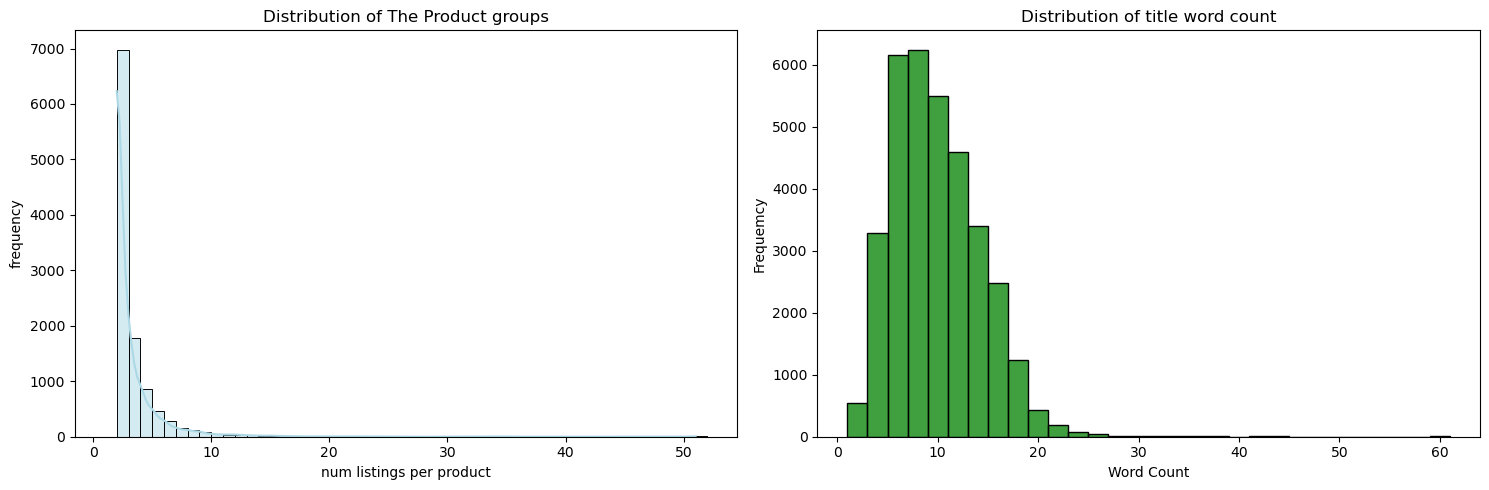

In [13]:
uniq_prods = df["label_group"].nunique()

print("Number of unique prdcts: ", uniq_prods)
print("Average listings: ", len(df)/uniq_prods)

group_sizes = df.groupby('label_group').size()

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.histplot(group_sizes, bins=range(1, group_sizes.max() + 2), kde=True, color = 'lightblue')
plt.title("Distribution of The Product groups")
plt.xlabel('num listings per product')
plt.ylabel('frequency')



uniq_imgs = df['image'].nunique()
unique_hashes = df["image_phash"].nunique()
print("Unique images: {unique_imgs} | Unique hashes: {unique_hashes}")

df["title_word_count"] = df["title"].apply(lambda x: len(str(x).split()))

plt.subplot(1, 2, 2)
sns.histplot(df['title_word_count'], bins=30, color="green")
plt.title("Distribution of title word count")
plt.xlabel('Word Count')
plt.ylabel('Frequemcy')

plt.tight_layout()
plt.show()

In [16]:
def visualize_grp(label_group_id, dframe, max_imgs=5):
    group_df= dframe[dframe['label_group'] == label_group_id].head(max_imgs)
    
    if len(group_df) == 0:
        print("Group not found")
        return
    
    fig, axes = plt.subplots(1, len(group_df), figsize=(20, 5))

    if len(group_df) == 1:
        axes=[axes]

    for ax, (_, row) in zip(axes, group_df.iterrows()):
        img_path = os.path.join(TRAIN_IMAGE_DIR, row['image'])
        try:
            img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
            ax.imshow(img)
        except Exception as e:
            ax.text(0.5, 0.5, 'Img Error', ha='center')

        title_disp = row['title'][:45] + '...' if len(row['title']) > 45 else row['title']
        ax.axis('off')

    plt.suptitle(f'Label Group: {label_group_id}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

largest_groups = df['label_group'].value_counts().head(20).index.tolist()
            

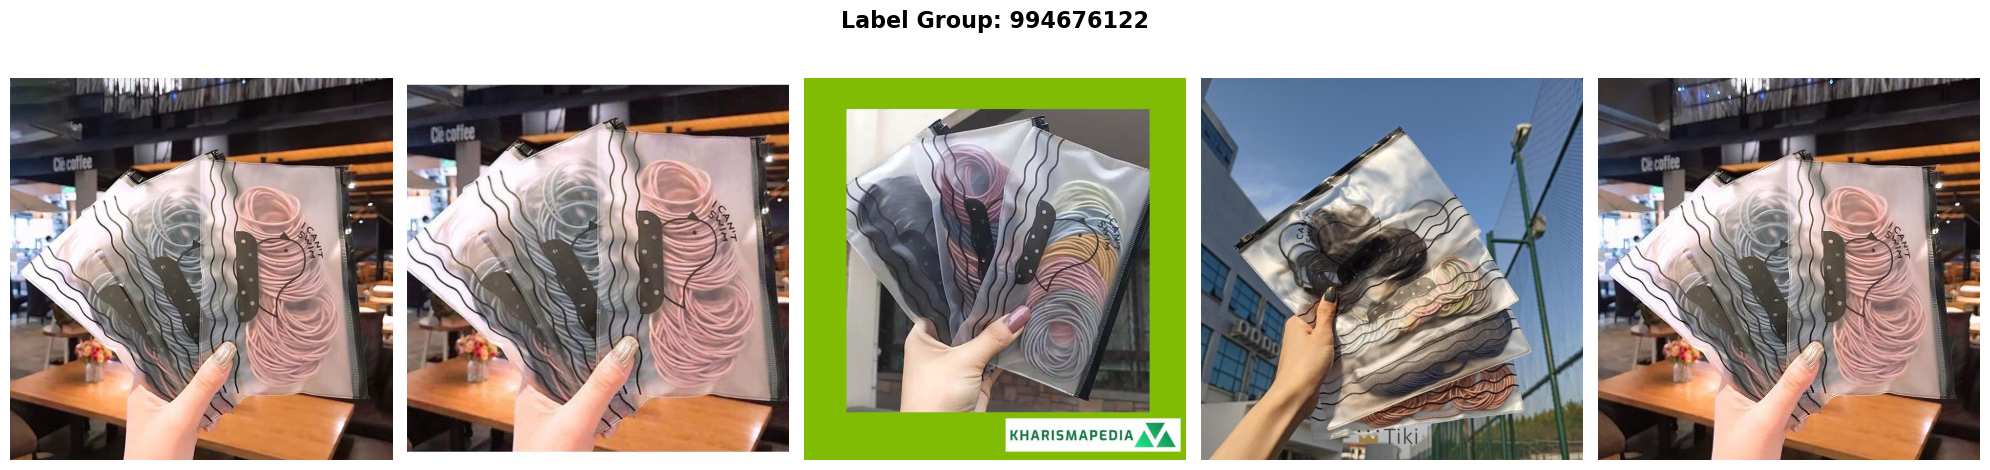

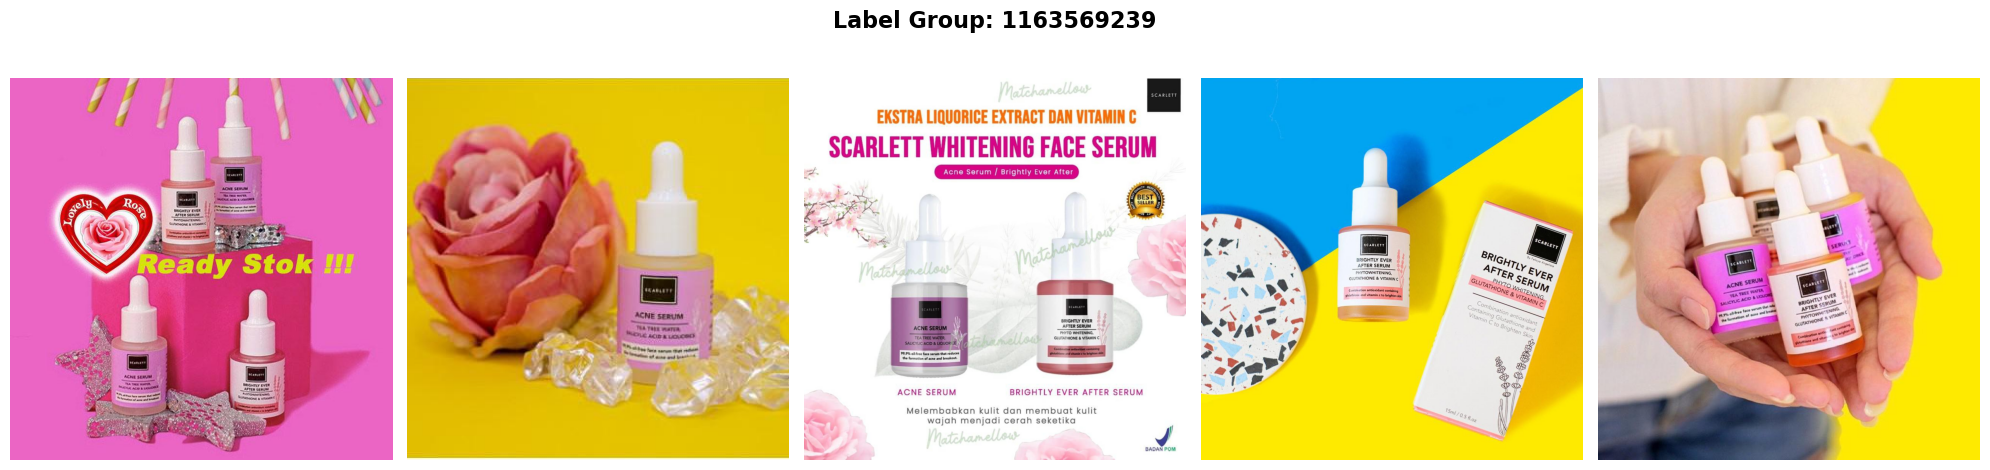

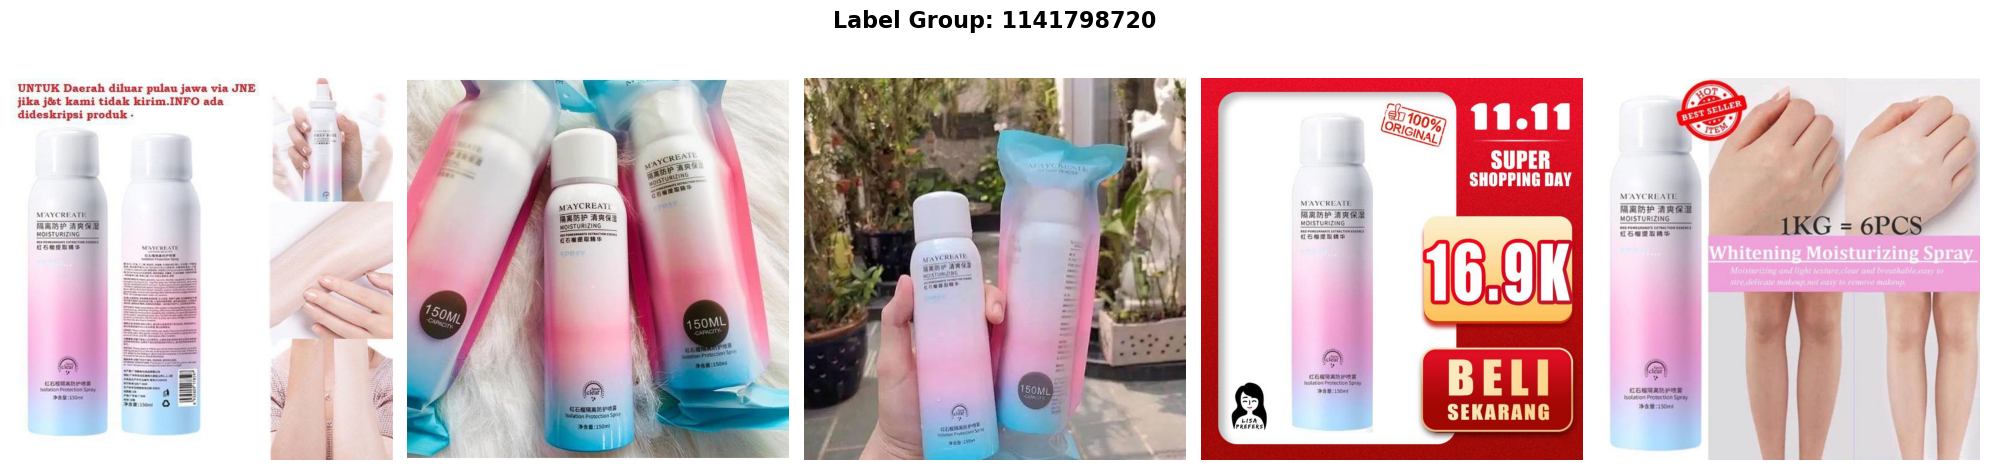

In [17]:
visualize_grp(largest_groups[0], df)

# Challenge 2: Noisy Text (Same product, different languages and keyword stuffing)
visualize_grp(largest_groups[1], df)

# Challenge 3: Incomplete descriptions
visualize_grp(largest_groups[2], df)